# Population Ruin

Data used:
- `population_ruin_data/population_ruin_reevo_tsp_constructive.txt`: `algorithm=reevo`, `problem=tsp_constructive`, stdout
- `population_ruin_data/population_ruin_eoh_tsp_constructive.txt`: `algorithm=eoh`, `problem=tsp_constructive`, stdout
- `population_ruin_data/population_ruin_ael_tsp_constructive.txt`: `algorithm=ael`, `problem=tsp_constructive`, stdout

In [17]:
def count_number_valid_solutions(filepath):
    with open(filepath) as f:
        output = f.read()
    """
    Count the number of valid solutions over iterations.

    `output` contains lines like:
    ```
    >>>[Evaluator] Evaluation successful: iter2_response0
    Obj: 21.65340166225336

    >>>[Evaluator] Evaluation successful: iter2_response1
    Obj: 25.793207687178285

    >>>[Evaluator] Evaluation successful: iter2_response2
    Obj: 7.424964488318715
    ```

    "iter2" means iteration index 2;
    for each iteration, count the number of "Evaluation successful" times.

    Args:
        filepath (str): filepath of stdout

    Returns:
        iteration_index (list[int]): list of iteration indices
        num_valid_solutions (list[int]): list of number of valid solutions; `num_valid_solutions[i]` counts the number of valid solutions at iteration `iteration_index[i]`
    """
    # Parse the output to count successful evaluations per iteration
    from collections import defaultdict

    iteration_counts = defaultdict(int)

    # Split by lines and process each line
    lines = output.split('\n')
    for line in lines:
        if '>>>[Evaluator] Evaluation successful:' in line:
            # Extract the iteration number from the pattern "iterX_responseY"
            # Example: ">>>[Evaluator] Evaluation successful: iter2_response0"
            parts = line.split(':')
            if len(parts) >= 2:
                iter_response = parts[-1].strip()
                # Extract iteration number from "iterX_responseY"
                if iter_response.startswith('iter'):
                    # Find the iteration number after "iter"
                    iter_str = iter_response[4:]  # Remove "iter"
                    # Find where the iteration number ends (before "_response")
                    if '_response' in iter_str:
                        iter_num_str = iter_str.split('_response')[0]
                        try:
                            iteration_num = int(iter_num_str)
                            iteration_counts[iteration_num] += 1
                        except ValueError:
                            # Skip if can't parse iteration number
                            continue

    # Convert to sorted lists
    iteration_index = sorted(iteration_counts.keys())
    num_valid_solutions = [iteration_counts[i] for i in iteration_index]

    return iteration_index, num_valid_solutions



=====Iteration index=====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]
=====Num of valid solutions=====
[1, 20, 10, 5, 9, 5, 10, 5, 10, 5, 10, 5, 4, 5, 9, 5, 10, 4, 10, 5, 9, 5, 9, 5, 4, 5, 7, 3, 9, 3, 6, 3, 6, 4, 7, 5, 3, 2, 6, 5, 2, 2, 0, 0]


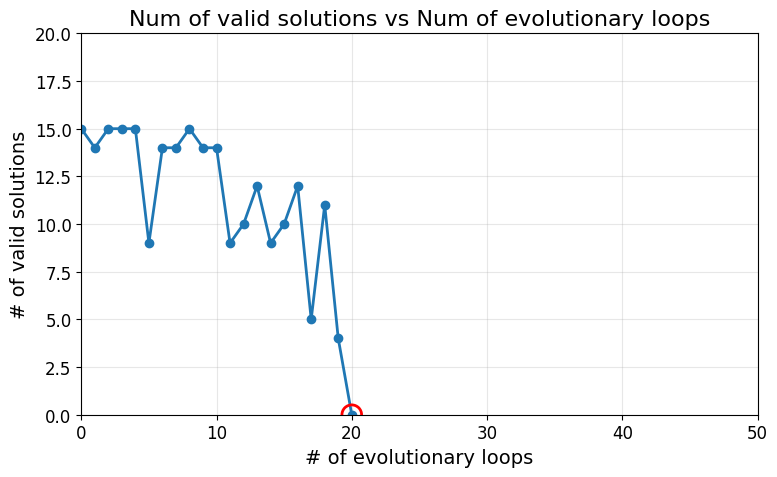

In [18]:
from plotlib import color_scheme, font_scheme


## ReEvo
iteration_index, num_valid_solutions = count_number_valid_solutions("population_ruin_data/population_ruin_reevo_tsp_constructive.txt")
iteration_index.append(42)
iteration_index.append(43)
num_valid_solutions.append(0)
num_valid_solutions.append(0)

print("=====Iteration index=====")
print(iteration_index)
print("=====Num of valid solutions=====")
print(num_valid_solutions)

assert len(iteration_index) == len(num_valid_solutions)


# even index for crossover
# odd index for mutation
# one cross-over + one mutation -> total number of valid solns at the end of one evolutionary loop
# cross-over pop has high # of valid solutions
# mutation pop low

iteration_index = iteration_index[2:]
num_valid_solutions = num_valid_solutions[2:]

assert len(iteration_index) % 2 == 0, len(iteration_index)

loop_index = list(range(len(iteration_index) // 2))
num_valid_solutions_per_loop = []

for i in range(0, len(num_valid_solutions), 2):
    crossover_and_mutation = num_valid_solutions[i] + num_valid_solutions[i + 1]
    num_valid_solutions_per_loop.append(crossover_and_mutation)

import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

plt.figure(figsize=(8, 5))
plt.plot(loop_index, num_valid_solutions_per_loop, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('# of evolutionary loops')
plt.xlim(0, 50)
plt.ylabel('# of valid solutions')
plt.ylim(0, 20)
plt.title('Num of valid solutions vs Num of evolutionary loops')
plt.grid(True, alpha=0.3)
plt.tight_layout()

for i, (x, y) in enumerate(zip(loop_index, num_valid_solutions_per_loop)):
    # Draw additional large red circles on nodes whose y axis value is zero
    if y == 0:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
        
    # Draw dashed large magenta circle on nodes whose y axis value is one
    if y == 1:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='magenta', linewidths=2, zorder=5)

plt.show()


=====Iteration index=====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167]
=====Num of valid solutions=====
[20, 10, 9, 10, 9, 10, 10, 9, 9, 10, 10, 9, 9, 10, 10, 10, 9, 7, 10, 10, 10, 10, 5, 10, 10, 10, 10, 7, 7, 6, 7, 7, 3, 5, 6, 9, 10, 5, 10, 7, 7, 9, 1, 9, 3, 6, 9, 9, 7, 9, 6, 8, 6, 6, 7, 10, 8, 9, 10, 10, 10, 10

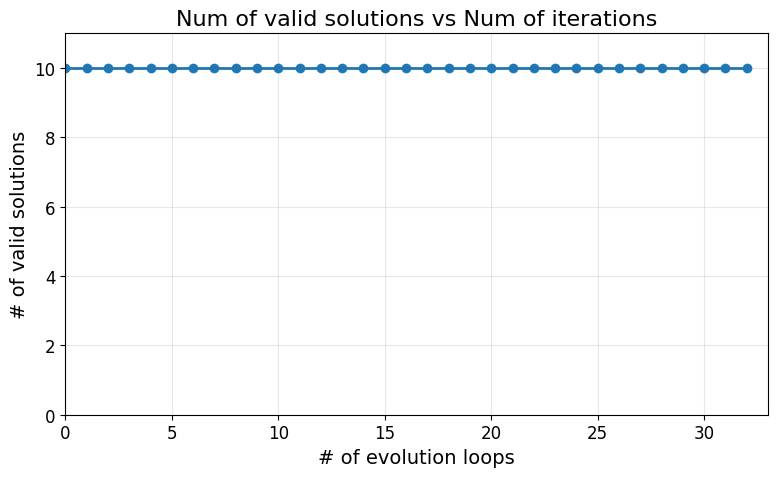

In [19]:
## EoH
from plotlib import color_scheme, font_scheme


iteration_index, num_valid_solutions = count_number_valid_solutions("population_ruin_data/population_ruin_eoh_tsp_constructive.txt")

print("=====Iteration index=====")
print(iteration_index)
print("=====Num of valid solutions=====")
print(num_valid_solutions)

assert len(iteration_index) == len(num_valid_solutions)

# iteration_index % 5 is the index of operations applied in one loop
# say, itr = 1 applies the first operation to population
# itr = 2 applies the second operation to population
# ...

iteration_index = iteration_index[1:166]
num_valid_solutions = num_valid_solutions[1:166]

assert len(iteration_index) % 5 == 0, len(iteration_index)

print(len(iteration_index))

loop_index = list(range(len(iteration_index) // 5))
num_valid_solutions_per_loop = []

for i in range(0, len(num_valid_solutions) // 5):
    crossover_and_mutation = sum(num_valid_solutions[i:i+5])
    num_valid_solutions_per_loop.append(min(10, crossover_and_mutation))


import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

plt.figure(figsize=(8, 5))
plt.plot(loop_index, num_valid_solutions_per_loop, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('# of evolution loops')
plt.xlim(0, 33)
plt.ylabel('# of valid solutions')
plt.ylim(0, 11)
plt.title('Num of valid solutions vs Num of iterations')
plt.grid(True, alpha=0.3)
plt.tight_layout()

for i, (x, y) in enumerate(zip(loop_index, num_valid_solutions_per_loop)):
    # Draw additional large red circles on nodes whose y axis value is zero
    if y == 0:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
        
    # Draw dashed large magenta circle on nodes whose y axis value is one
    if y == 1:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='magenta', linewidths=2, zorder=5)

plt.show()

=====Iteration index=====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
=====Num of valid solutions=====
[20, 13, 12, 12, 4, 11, 13, 12, 9, 11, 16, 11, 13, 15, 15, 12, 10, 14, 17, 14, 13, 13, 12, 11, 16, 13, 15, 16, 14, 10, 8, 12, 9, 14, 5, 14, 14, 12, 14, 10, 12, 16, 9, 11, 10, 13, 16, 14, 15, 17, 12, 17, 9, 12, 16, 14, 16, 12, 14, 15, 14, 16, 12, 16, 17, 14, 17, 17, 10, 17, 11, 15, 11, 11, 14, 13, 11, 16, 12, 11, 9]


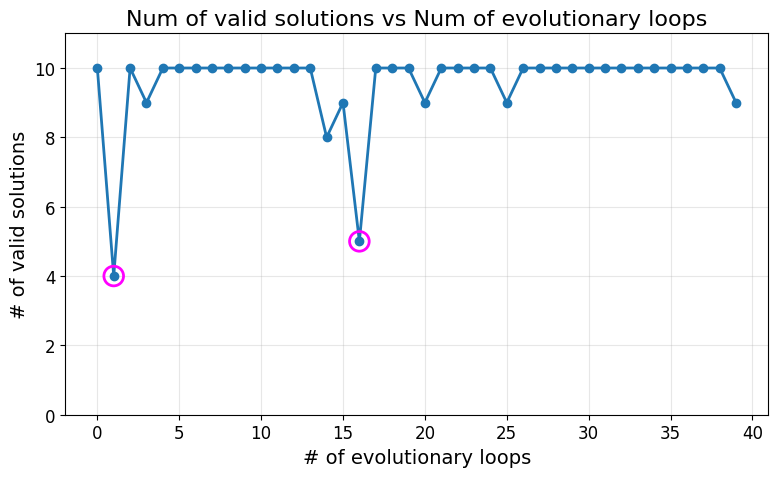

In [20]:
## AEL
from plotlib import color_scheme, font_scheme


iteration_index, num_valid_solutions = count_number_valid_solutions("population_ruin_data/population_ruin_ael_tsp_constructive.txt")

print("=====Iteration index=====")
print(iteration_index)
print("=====Num of valid solutions=====")
print(num_valid_solutions)

assert len(iteration_index) == len(num_valid_solutions)

# iteration_index % 2 == 1 means generated crossover pop
# iteration_index % 2 == 0 means subsequent mutation on the crossover pop

iteration_index = iteration_index[1:]
num_valid_solutions = num_valid_solutions[1:]

loop_index = list(range(len(iteration_index) // 2))
num_valid_solutions_per_loop = []

for i in range(0, len(num_valid_solutions), 2):
    crossover_and_mutation = min(10, num_valid_solutions[i + 1])
    num_valid_solutions_per_loop.append(crossover_and_mutation)
    

import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

plt.figure(figsize=(8, 5))
plt.plot(loop_index, num_valid_solutions_per_loop, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('# of evolutionary loops')
plt.ylabel('# of valid solutions')
plt.ylim(0, 11)
plt.title('Num of valid solutions vs Num of evolutionary loops')
plt.grid(True, alpha=0.3)
plt.tight_layout()

for i, (x, y) in enumerate(zip(loop_index, num_valid_solutions_per_loop)):
    # Draw additional large red circles on nodes whose y axis value is zero
    if y == 0:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
        
    # Draw dashed large magenta circle on nodes whose y axis value is one
    if y <= 5:
        plt.scatter(x, y, s=200, facecolors='none', edgecolors='magenta', linewidths=2, zorder=5)

plt.show()